# Week 3 Notebook 03

## 微电网测试系统构建与三相场景生成

本 notebook 将 Week 2 的三相潮流模型扩展为一个可复用的 **scenario generation engine**，用于后续 microgrid security prediction。

Week 3 **不生成 N-1 labels**。本周只生成一组经过验证的 base-case operating scenarios：

$$
 x_t = \{\text{three-phase load, PV, BESS setpoint, base-case voltage/current/VUF}\}.
$$

Week 4 会把每个 operating scenario 和 contingency \(c\) 组合起来做 N-1 scan：

$$
(x_t, c) \rightarrow \text{post-contingency violation label}.
$$

### 本周输出

- deterministic scenario table；
- PV 与 BESS-like device configuration；
- base-case three-phase power-flow summary；
- AI-facing scalar features；
- validation table，证明场景引擎 reset-safe、符号一致、物理账本正确。

## 0. 环境设置

需要的 Python 包：

```bash
pip install pandapower pandas numpy networkx matplotlib
```

教学提示：第一次调用 `runpp_3ph()` 可能略慢，因为数值例程需要初始化；后续场景通常会更快。

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import copy
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

try:
    import pandapower as pp
    import pandapower.networks as pn
    import pandapower.topology as top
except ImportError as exc:
    raise ImportError("This notebook requires pandapower. Install it with `pip install pandapower`.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

SEED = 2026
rng = np.random.default_rng(SEED)


def find_course_root(start: Path | None = None) -> Path:
    """Locate the repository root whether Jupyter starts here or in notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "00_overview").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the course repository root. Open this notebook from the cloned repository."
    )


PROJECT_ROOT = find_course_root()

OUTPUT_DIR = PROJECT_ROOT / "03_week03_microgrid_scenario_generation" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PHASES = ["a", "b", "c"]
P_COLS = {ph: f"p_{ph}_mw" for ph in PHASES}
Q_COLS = {ph: f"q_{ph}_mvar" for ph in PHASES}
VM_COLS = [f"vm_{ph}_pu" for ph in PHASES]
VA_COLS = [f"va_{ph}_degree" for ph in PHASES]

TOL_ACTIVE_BALANCE_MW = 1e-5
TOL_VUF_PERCENT = 1e-8
TOL_LOADING_PERCENT = 1e-8
TOL_REPRO = 1e-10

print(f"pandapower version: {pp.__version__}")
print(f"Output directory: {OUTPUT_DIR}")


pandapower version: 3.2.1
Output directory: /Users/buxinshe/Git-repo/PINN-Microgrid-Prediction/03_week03_microgrid_scenario_generation/outputs


## 1. Full feeder 与 teaching feeder 的关系

科研项目后续可以使用 pandapower 内置的 `ieee_european_lv_asymmetric` 大型低压 feeder。它很适合作为 LV feeder proxy，但对第一版课堂 scenario-generation lab 来说规模偏大。

因此 Week 3 采用一个 compact **microgrid teaching feeder**：

- 课堂运行速度快；
- 保留三相不平衡建模思想；
- 包含 PV、BESS、critical load、EV load 和不平衡场景；
- 每个 validation step 都可以被学生手动检查。

学生理解 pipeline 后，可以把 teaching feeder 替换成完整的 `ieee_european_lv_asymmetric` 或其 reduced feeder。

In [2]:
def inspect_full_ieee_lv_feeder_metadata() -> pd.Series:
    """Load metadata for the full IEEE European LV asymmetric feeder without running power flow."""
    net = pn.ieee_european_lv_asymmetric(scenario="on_peak_566")
    counts = {
        "bus": len(net.bus),
        "line": len(net.line),
        "trafo": len(net.trafo),
        "ext_grid": len(net.ext_grid),
        "asymmetric_load": len(net.asymmetric_load),
        "nominal_lv_kv_min": float(net.bus.vn_kv.min()),
        "nominal_lv_kv_max": float(net.bus.vn_kv.max()),
    }
    return pd.Series(counts, name="ieee_european_lv_asymmetric_metadata")

full_feeder_metadata = inspect_full_ieee_lv_feeder_metadata()
display(full_feeder_metadata.to_frame())


,ieee_european_lv_asymmetric_metadata
bus,907.000
line,905.000
trafo,1.000
ext_grid,1.000
asymmetric_load,55.000
nominal_lv_kv_min,0.416
nominal_lv_kv_max,11.000


## 2. 构建 compact microgrid teaching feeder

这个 teaching feeder 是一个径向 0.4 kV microgrid-like feeder，包含：

- 一个 PCC / slack equivalent；
- critical、residential、EV、remote、medical loads；
- 单相与三相 PV placeholder；
- 一个 BESS-like static setpoint，用 asymmetric generation 或 asymmetric load 表示。

Week 3 中 BESS **不是**时域 SOC 模型。我们只需要静态 dispatch setpoint：

- `bess_p_discharge_mw > 0` 表示 BESS 放电注入；
- `bess_p_discharge_mw < 0` 表示 BESS 充电消耗。

这样做是为了把课程重点放在场景生成和三相潮流验证上。SOC 动态可在 time-series extension 中加入。

In [3]:
@dataclass(frozen=True)
class MicrogridMetadata:
    bus_map: dict[str, int]
    line_names: list[str]
    original_load_indices: list[int]
    pv_config: pd.DataFrame
    bess_config: pd.DataFrame


def create_microgrid_teaching_feeder() -> tuple[pp.pandapowerNet, MicrogridMetadata]:
    """Create a compact three-phase microgrid feeder for scenario generation.

    The network is intentionally small so that students can inspect all input
    and result tables. It is not intended to represent a particular field feeder.
    """
    net = pp.create_empty_network(name="week3_microgrid_teaching_feeder", sn_mva=1.0)

    bus_names = [
        "PCC_0p4kV",
        "Main_bus",
        "Critical_load_bus",
        "Residential_bus",
        "PV_A_bus",
        "PV_C_bus",
        "EV_bus",
        "Remote_bus",
        "Medical_bus",
    ]
    bus_map = {name: pp.create_bus(net, vn_kv=0.4, name=name) for name in bus_names}

    pp.create_ext_grid(
        net,
        bus=bus_map["PCC_0p4kV"],
        vm_pu=1.0,
        va_degree=0.0,
        name="PCC_slack_grid_connected",
        s_sc_max_mva=50.0,
        s_sc_min_mva=40.0,
        rx_max=0.10,
        rx_min=0.10,
        x0x_max=1.0,
        x0x_min=1.0,
        r0x0_max=0.10,
        r0x0_min=0.10,
    )

    # The line parameters are plausible teaching values for LV cable-like branches.
    line_specs = [
        ("PCC_0p4kV", "Main_bus", 0.020, "L0_PCC_to_main"),
        ("Main_bus", "Critical_load_bus", 0.030, "L1_main_to_critical"),
        ("Main_bus", "Residential_bus", 0.035, "L2_main_to_residential"),
        ("Residential_bus", "PV_A_bus", 0.030, "L3_residential_to_pvA"),
        ("Residential_bus", "PV_C_bus", 0.030, "L4_residential_to_pvC"),
        ("Critical_load_bus", "EV_bus", 0.035, "L5_critical_to_ev"),
        ("EV_bus", "Remote_bus", 0.040, "L6_ev_to_remote"),
        ("Critical_load_bus", "Medical_bus", 0.020, "L7_critical_to_medical"),
    ]
    line_names = []
    for from_name, to_name, length_km, name in line_specs:
        pp.create_line_from_parameters(
            net,
            from_bus=bus_map[from_name],
            to_bus=bus_map[to_name],
            length_km=length_km,
            r_ohm_per_km=0.642,
            x_ohm_per_km=0.083,
            c_nf_per_km=210.0,
            max_i_ka=0.25,
            r0_ohm_per_km=1.80,
            x0_ohm_per_km=0.25,
            c0_nf_per_km=70.0,
            name=name,
        )
        line_names.append(name)

    # Base loads in MW/Mvar by phase. These are sized to create visible but not excessive voltage stress.
    load_specs = [
        ("Critical_load_bus", (0.006, 0.005, 0.006), (0.0012, 0.0010, 0.0012), "critical_load"),
        ("Residential_bus", (0.005, 0.007, 0.004), (0.0010, 0.0014, 0.0008), "residential_load"),
        ("EV_bus", (0.003, 0.008, 0.003), (0.0006, 0.0016, 0.0006), "ev_b_phase_heavy_load"),
        ("Remote_bus", (0.004, 0.002, 0.005), (0.0008, 0.0004, 0.0010), "remote_load"),
        ("Medical_bus", (0.003, 0.004, 0.003), (0.0006, 0.0008, 0.0006), "medical_critical_load"),
    ]
    original_load_indices = []
    for bus_name, p_vals, q_vals, name in load_specs:
        idx = pp.create_asymmetric_load(
            net,
            bus=bus_map[bus_name],
            p_a_mw=p_vals[0], p_b_mw=p_vals[1], p_c_mw=p_vals[2],
            q_a_mvar=q_vals[0], q_b_mvar=q_vals[1], q_c_mvar=q_vals[2],
            type="wye",
            name=name,
        )
        original_load_indices.append(int(idx))

    pv_rows = []
    pv_specs = [
        ("PV_A_bus", "a", 0.006, "PV_single_phase_A"),
        ("PV_C_bus", "c", 0.006, "PV_single_phase_C"),
        ("Remote_bus", "abc", 0.006, "PV_three_phase_remote"),
    ]
    for bus_name, phase, rating_mw, name in pv_specs:
        idx = pp.create_asymmetric_sgen(
            net,
            bus=bus_map[bus_name],
            p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
            q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
            type="wye",
            name=name,
        )
        pv_rows.append({"idx": int(idx), "bus_name": bus_name, "bus": int(bus_map[bus_name]), "phase": phase, "rating_mw": rating_mw, "name": name})
    pv_config = pd.DataFrame(pv_rows)

    bess_sgen_idx = pp.create_asymmetric_sgen(
        net,
        bus=bus_map["Medical_bus"],
        p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
        q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
        type="wye",
        name="BESS_static_discharge_model",
    )
    bess_load_idx = pp.create_asymmetric_load(
        net,
        bus=bus_map["Medical_bus"],
        p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
        q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
        type="wye",
        name="BESS_static_charge_model",
    )
    bess_config = pd.DataFrame([
        {
            "bus_name": "Medical_bus",
            "bus": int(bus_map["Medical_bus"]),
            "discharge_sgen_idx": int(bess_sgen_idx),
            "charge_load_idx": int(bess_load_idx),
            "rating_mw": 0.012,
            "description": "positive setpoint -> asymmetric_sgen; negative setpoint -> asymmetric_load",
        }
    ])

    metadata = MicrogridMetadata(
        bus_map={k: int(v) for k, v in bus_map.items()},
        line_names=line_names,
        original_load_indices=original_load_indices,
        pv_config=pv_config,
        bess_config=bess_config,
    )
    return net, metadata


base_net, metadata = create_microgrid_teaching_feeder()
print(base_net)
display(metadata.pv_config)
display(metadata.bess_config)


This pandapower network includes the following parameter tables:
   - bus (9 elements)
   - asymmetric_load (6 elements)
   - asymmetric_sgen (4 elements)
   - ext_grid (1 element)
   - line (8 elements)


,idx,bus_name,bus,phase,rating_mw,name
0,0,PV_A_bus,4,a,0.006,PV_single_phase_A
1,1,PV_C_bus,5,c,0.006,PV_single_phase_C
2,2,Remote_bus,7,abc,0.006,PV_three_phase_remote


,bus_name,bus,discharge_sgen_idx,charge_load_idx,rating_mw,description
0,Medical_bus,8,3,5,0.012,positive setpoint -> asymmetric_sgen; negative...


### Proof check 1: 输入网络完整性

生成场景前，先验证静态网络本身：

1. 必要数据表存在；
2. 每个 element 都引用有效 bus；
3. line zero-sequence 参数存在，因为三相潮流需要序网络信息；
4. 从 PCC 看网络连通且为径向结构；
5. PV 和 BESS-like devices 都引用有效 bus。

In [4]:
def build_feeder_graph(net: pp.pandapowerNet) -> nx.Graph:
    """Build an undirected graph from in-service lines only."""
    G = nx.Graph()
    for bus in net.bus.index.astype(int):
        G.add_node(int(bus))
    for line_idx, row in net.line.iterrows():
        if bool(row.get("in_service", True)):
            G.add_edge(int(row.from_bus), int(row.to_bus), element="line", index=int(line_idx))
    return G


def assert_input_network_integrity(net: pp.pandapowerNet, metadata: MicrogridMetadata) -> dict:
    required_tables = ["bus", "line", "ext_grid", "asymmetric_load", "asymmetric_sgen"]
    for tbl in required_tables:
        assert hasattr(net, tbl), f"Missing net.{tbl}"

    assert len(net.ext_grid) == 1, "Week 3 teaching feeder expects exactly one PCC/slack equivalent."
    assert len(net.bus) == 9, "Unexpected bus count."
    assert len(net.line) == 8, "Unexpected line count."

    bus_set = set(net.bus.index.astype(int))
    assert set(net.line.from_bus.astype(int)).issubset(bus_set)
    assert set(net.line.to_bus.astype(int)).issubset(bus_set)
    assert set(net.asymmetric_load.bus.astype(int)).issubset(bus_set)
    assert set(net.asymmetric_sgen.bus.astype(int)).issubset(bus_set)
    assert set(net.ext_grid.bus.astype(int)).issubset(bus_set)

    zero_seq_cols = ["r0_ohm_per_km", "x0_ohm_per_km", "c0_nf_per_km"]
    missing_zero_seq = [c for c in zero_seq_cols if c not in net.line.columns]
    assert not missing_zero_seq, f"Missing line zero-sequence columns: {missing_zero_seq}"
    assert net.line[zero_seq_cols].notna().all().all(), "Zero-sequence line parameters contain NaN values."
    assert (net.line.length_km > 0).all(), "All line lengths must be positive."
    assert (net.line.max_i_ka > 0).all(), "All line current limits must be positive."

    G = build_feeder_graph(net)
    pcc_bus = int(net.ext_grid.bus.iloc[0])
    assert nx.is_connected(G), "Feeder graph should be connected."
    assert G.number_of_edges() == G.number_of_nodes() - 1, "Teaching feeder is expected to be radial."
    assert len(nx.single_source_shortest_path_length(G, pcc_bus)) == len(net.bus), "All buses should be reachable from PCC."

    pv = metadata.pv_config
    assert not pv.empty, "PV configuration should not be empty."
    assert set(pv["idx"].astype(int)).issubset(set(net.asymmetric_sgen.index.astype(int)))
    assert set(pv["bus"].astype(int)).issubset(bus_set)
    assert set(pv["phase"]).issubset({"a", "b", "c", "abc"})

    bess = metadata.bess_config.iloc[0]
    assert int(bess.discharge_sgen_idx) in set(net.asymmetric_sgen.index.astype(int))
    assert int(bess.charge_load_idx) in set(net.asymmetric_load.index.astype(int))

    return {
        "status": "passed",
        "n_bus": len(net.bus),
        "n_line": len(net.line),
        "n_asymmetric_load": len(net.asymmetric_load),
        "n_asymmetric_sgen": len(net.asymmetric_sgen),
        "radial": True,
        "connected": True,
    }

input_integrity = assert_input_network_integrity(base_net, metadata)
display(pd.Series(input_integrity, name="input_network_integrity").to_frame())


,input_network_integrity
status,passed
n_bus,9
n_line,8
n_asymmetric_load,6
n_asymmetric_sgen,4
radial,True
connected,True


## 3. 定义 deterministic 与 random operating scenarios

一个 scenario 是一个 base-case operating point，还不包含 contingency。

确定性场景用于制造可解释的运行状态：

- `high_load`: 电压跌落与 loading 压力；
- `high_pv_midday`: 低负荷高 PV，PCC import 下降并可能出现电压升高；
- `phase_b_heavy`: B 相重载，制造电压不平衡；
- `evening_peak_bess_discharge`: 晚高峰，BESS 放电支撑；
- `bess_charging`: 额外充电需求；
- `stress_unbalance`: 故意制造较困难的安全筛查场景。

In [5]:
SCENARIO_TABLE = pd.DataFrame([
    {
        "scenario_id": "base",
        "load_scale": 1.00,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.00,
        "phase_c_factor": 1.00,
        "pv_scale": 0.00,
        "bess_p_discharge_mw": 0.000,
        "mode": "grid_connected",
        "description": "reference microgrid operating point",
    },
    {
        "scenario_id": "high_load",
        "load_scale": 1.25,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.00,
        "phase_c_factor": 1.00,
        "pv_scale": 0.00,
        "bess_p_discharge_mw": 0.000,
        "mode": "grid_connected",
        "description": "uniform high-load condition",
    },
    {
        "scenario_id": "high_pv_midday",
        "load_scale": 0.75,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.00,
        "phase_c_factor": 1.00,
        "pv_scale": 1.00,
        "bess_p_discharge_mw": 0.000,
        "mode": "grid_connected",
        "description": "low load with high PV generation",
    },
    {
        "scenario_id": "phase_b_heavy",
        "load_scale": 1.00,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.60,
        "phase_c_factor": 1.00,
        "pv_scale": 0.00,
        "bess_p_discharge_mw": 0.000,
        "mode": "grid_connected",
        "description": "B-phase-heavy demand pattern",
    },
    {
        "scenario_id": "evening_peak_bess_discharge",
        "load_scale": 1.30,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.20,
        "phase_c_factor": 1.00,
        "pv_scale": 0.10,
        "bess_p_discharge_mw": 0.008,
        "mode": "grid_connected",
        "description": "evening peak with small PV and BESS discharge",
    },
    {
        "scenario_id": "bess_charging",
        "load_scale": 1.00,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.00,
        "phase_c_factor": 1.00,
        "pv_scale": 0.20,
        "bess_p_discharge_mw": -0.008,
        "mode": "grid_connected",
        "description": "base load with PV and BESS charging",
    },
    {
        "scenario_id": "stress_unbalance",
        "load_scale": 1.35,
        "phase_a_factor": 1.00,
        "phase_b_factor": 1.60,
        "phase_c_factor": 0.80,
        "pv_scale": 0.80,
        "bess_p_discharge_mw": -0.008,
        "mode": "grid_connected",
        "description": "combined high load, B-phase stress, PV, and charging",
    },
])

def sample_random_scenarios(n: int = 20, seed: int = SEED) -> pd.DataFrame:
    """Generate reproducible random scenarios for later AI dataset expansion."""
    local_rng = np.random.default_rng(seed)
    rows = []
    for k in range(n):
        phase_factors = np.clip(local_rng.normal(loc=1.0, scale=0.18, size=3), 0.70, 1.60)
        rows.append({
            "scenario_id": f"random_{k:03d}",
            "load_scale": float(local_rng.uniform(0.70, 1.35)),
            "phase_a_factor": float(phase_factors[0]),
            "phase_b_factor": float(phase_factors[1]),
            "phase_c_factor": float(phase_factors[2]),
            "pv_scale": float(local_rng.beta(2.0, 2.0)),
            "bess_p_discharge_mw": float(local_rng.uniform(-0.008, 0.008)),
            "mode": "grid_connected",
            "description": "random training candidate",
        })
    return pd.DataFrame(rows)


def assert_scenario_table_schema(df: pd.DataFrame) -> dict:
    required = [
        "scenario_id", "load_scale", "phase_a_factor", "phase_b_factor", "phase_c_factor",
        "pv_scale", "bess_p_discharge_mw", "mode", "description",
    ]
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"Missing scenario table columns: {missing}"
    assert df["scenario_id"].is_unique, "scenario_id must be unique."
    assert (df["load_scale"] > 0).all(), "load_scale must be positive."
    assert df[["phase_a_factor", "phase_b_factor", "phase_c_factor"]].gt(0).all().all(), "phase factors must be positive."
    assert df["pv_scale"].between(0, 1.2).all(), "pv_scale outside expected teaching range."
    assert set(df["mode"]) == {"grid_connected"}, "Week 3 MVP uses grid-connected mode only."
    return {"status": "passed", "n_scenarios": len(df), "n_columns": len(df.columns)}

scenario_schema_check = assert_scenario_table_schema(SCENARIO_TABLE)
display(SCENARIO_TABLE)
display(pd.Series(scenario_schema_check, name="scenario_schema_check").to_frame())

random_a = sample_random_scenarios(5, seed=SEED)
random_b = sample_random_scenarios(5, seed=SEED)
random_c = sample_random_scenarios(5, seed=SEED + 1)
assert random_a.equals(random_b), "Random scenario sampler is not reproducible for the same seed."
assert not random_a.equals(random_c), "Different random seeds should produce different scenario samples."
display(random_a)


,scenario_id,load_scale,phase_a_factor,phase_b_factor,phase_c_factor,pv_scale,bess_p_discharge_mw,mode,description
0,base,1.00,1.0,1.0,1.0,0.0,0.000,grid_connected,reference microgrid operating point
1,high_load,1.25,1.0,1.0,1.0,0.0,0.000,grid_connected,uniform high-load condition
2,high_pv_midday,0.75,1.0,1.0,1.0,1.0,0.000,grid_connected,low load with high PV generation
3,phase_b_heavy,1.00,1.0,1.6,1.0,0.0,0.000,grid_connected,B-phase-heavy demand pattern
4,evening_peak_bess_discharge,1.30,1.0,1.2,1.0,0.1,0.008,grid_connected,evening peak with small PV and BESS discharge
5,bess_charging,1.00,1.0,1.0,1.0,0.2,-0.008,grid_connected,base load with PV and BESS charging
6,stress_unbalance,1.35,1.0,1.6,0.8,0.8,-0.008,grid_connected,"combined high load, B-phase stress, PV, and ch..."


,scenario_schema_check
status,passed
n_scenarios,7
n_columns,9


,scenario_id,load_scale,phase_a_factor,phase_b_factor,phase_c_factor,pv_scale,bess_p_discharge_mw,mode,description
0,random_000,0.940825,0.857238,1.043303,0.700000,0.670310,0.002445,grid_connected,random training candidate
1,random_001,1.113316,0.959336,1.129612,1.092647,0.610852,-0.002579,grid_connected,random training candidate
2,random_002,0.980093,0.976513,0.752603,0.914090,0.343989,-0.004874,grid_connected,random training candidate
3,random_003,0.836120,1.242677,0.778598,1.031496,0.531288,-0.001076,grid_connected,random training candidate
4,random_004,0.903983,0.906578,0.917671,1.091177,0.705524,0.001280,grid_connected,random training candidate


## 4. Scenario application engine

最重要的工程规则是：

> 每次应用新 scenario 前，必须先 reset 到 base input state。

如果不 reset，负荷、PV 和 BESS 的 multiplier 会静默累积，导致数据集无效。

下面的函数完成：

1. 恢复原始 load 和 device tables；
2. 应用 load scale 和 phase multipliers；
3. 设置 PV 有功注入；
4. 把 BESS 放电映射到 `asymmetric_sgen`，把 BESS 充电映射到 `asymmetric_load`；
5. 生成 input signature，用于 idempotence proof。

In [6]:
def clone_base_feeder() -> tuple[pp.pandapowerNet, MicrogridMetadata, pd.DataFrame, pd.DataFrame]:
    """Create a fresh feeder plus input snapshots for reset-safe scenario application."""
    net, meta = create_microgrid_teaching_feeder()
    base_load_snapshot = net.asymmetric_load.copy(deep=True)
    base_sgen_snapshot = net.asymmetric_sgen.copy(deep=True)
    return net, meta, base_load_snapshot, base_sgen_snapshot


def reset_input_state(net: pp.pandapowerNet, base_load_snapshot: pd.DataFrame, base_sgen_snapshot: pd.DataFrame) -> None:
    """Restore asymmetric load and sgen input powers exactly."""
    cols = list(P_COLS.values()) + list(Q_COLS.values())
    net.asymmetric_load.loc[:, cols] = base_load_snapshot.loc[:, cols]
    net.asymmetric_sgen.loc[:, cols] = base_sgen_snapshot.loc[:, cols]


def apply_pv_setpoints(net: pp.pandapowerNet, meta: MicrogridMetadata, pv_scale: float) -> None:
    """Apply PV setpoints based on phase-specific rating and scenario scale."""
    for _, row in meta.pv_config.iterrows():
        idx = int(row["idx"])
        rating = float(row["rating_mw"])
        phase = row["phase"]
        if phase == "abc":
            for ph in PHASES:
                net.asymmetric_sgen.loc[idx, P_COLS[ph]] = rating * pv_scale / 3.0
        else:
            net.asymmetric_sgen.loc[idx, P_COLS[phase]] = rating * pv_scale


def apply_bess_setpoint(net: pp.pandapowerNet, meta: MicrogridMetadata, bess_p_discharge_mw: float) -> None:
    """Apply BESS static setpoint.

    Positive value -> discharge/injection through asymmetric_sgen.
    Negative value -> charging/consumption through asymmetric_load.
    """
    bess = meta.bess_config.iloc[0]
    discharge_idx = int(bess["discharge_sgen_idx"])
    charge_idx = int(bess["charge_load_idx"])
    rating = float(bess["rating_mw"])

    assert abs(bess_p_discharge_mw) <= rating + 1e-12, "BESS setpoint exceeds teaching rating."

    if bess_p_discharge_mw >= 0:
        for ph in PHASES:
            net.asymmetric_sgen.loc[discharge_idx, P_COLS[ph]] = bess_p_discharge_mw / 3.0
            net.asymmetric_load.loc[charge_idx, P_COLS[ph]] = 0.0
    else:
        charging_power = -bess_p_discharge_mw
        for ph in PHASES:
            net.asymmetric_load.loc[charge_idx, P_COLS[ph]] = charging_power / 3.0
            net.asymmetric_sgen.loc[discharge_idx, P_COLS[ph]] = 0.0


def apply_scenario(
    net: pp.pandapowerNet,
    meta: MicrogridMetadata,
    scenario: pd.Series | dict,
    base_load_snapshot: pd.DataFrame,
    base_sgen_snapshot: pd.DataFrame,
) -> None:
    """Reset the feeder and apply one operating scenario."""
    if isinstance(scenario, pd.Series):
        scenario = scenario.to_dict()

    reset_input_state(net, base_load_snapshot, base_sgen_snapshot)
    original_idx = meta.original_load_indices

    phase_factors = {
        "a": float(scenario["phase_a_factor"]),
        "b": float(scenario["phase_b_factor"]),
        "c": float(scenario["phase_c_factor"]),
    }
    load_scale = float(scenario["load_scale"])

    for ph in PHASES:
        p_col, q_col = P_COLS[ph], Q_COLS[ph]
        net.asymmetric_load.loc[original_idx, p_col] = base_load_snapshot.loc[original_idx, p_col] * load_scale * phase_factors[ph]
        net.asymmetric_load.loc[original_idx, q_col] = base_load_snapshot.loc[original_idx, q_col] * load_scale * phase_factors[ph]

    apply_pv_setpoints(net, meta, float(scenario["pv_scale"]))
    apply_bess_setpoint(net, meta, float(scenario["bess_p_discharge_mw"]))


def input_signature(net: pp.pandapowerNet) -> pd.Series:
    """Compact deterministic signature of input P/Q tables."""
    sig = {}
    for table_name in ["asymmetric_load", "asymmetric_sgen"]:
        table = getattr(net, table_name)
        for col in list(P_COLS.values()) + list(Q_COLS.values()):
            sig[f"{table_name}.{col}.sum"] = float(table[col].sum())
            sig[f"{table_name}.{col}.abs_sum"] = float(table[col].abs().sum())
    return pd.Series(sig)


def assert_scenario_application_idempotence() -> dict:
    """Applying the same scenario twice with reset should produce identical input signatures."""
    net, meta, load_snapshot, sgen_snapshot = clone_base_feeder()
    scenario = SCENARIO_TABLE.set_index("scenario_id").loc["stress_unbalance"]

    apply_scenario(net, meta, scenario, load_snapshot, sgen_snapshot)
    sig1 = input_signature(net)
    apply_scenario(net, meta, scenario, load_snapshot, sgen_snapshot)
    sig2 = input_signature(net)

    max_abs_diff = float((sig1 - sig2).abs().max())
    assert max_abs_diff < TOL_REPRO, f"Scenario application is not idempotent. Max diff = {max_abs_diff}"
    return {"status": "passed", "max_abs_input_signature_diff": max_abs_diff}


def assert_bess_sign_convention() -> dict:
    """Validate that positive BESS setpoint maps to sgen and negative maps to load."""
    net, meta, load_snapshot, sgen_snapshot = clone_base_feeder()

    discharge_case = SCENARIO_TABLE.set_index("scenario_id").loc["evening_peak_bess_discharge"]
    charge_case = SCENARIO_TABLE.set_index("scenario_id").loc["bess_charging"]

    apply_scenario(net, meta, discharge_case, load_snapshot, sgen_snapshot)
    bess = meta.bess_config.iloc[0]
    discharge_idx = int(bess.discharge_sgen_idx)
    charge_idx = int(bess.charge_load_idx)
    discharge_sgen_p = float(net.asymmetric_sgen.loc[discharge_idx, list(P_COLS.values())].sum())
    discharge_load_p = float(net.asymmetric_load.loc[charge_idx, list(P_COLS.values())].sum())
    assert discharge_sgen_p > 0 and abs(discharge_load_p) < 1e-12

    apply_scenario(net, meta, charge_case, load_snapshot, sgen_snapshot)
    charge_sgen_p = float(net.asymmetric_sgen.loc[discharge_idx, list(P_COLS.values())].sum())
    charge_load_p = float(net.asymmetric_load.loc[charge_idx, list(P_COLS.values())].sum())
    assert abs(charge_sgen_p) < 1e-12 and charge_load_p > 0

    return {
        "status": "passed",
        "discharge_case_sgen_mw": discharge_sgen_p,
        "discharge_case_charge_load_mw": discharge_load_p,
        "charge_case_sgen_mw": charge_sgen_p,
        "charge_case_charge_load_mw": charge_load_p,
    }

idempotence_check = assert_scenario_application_idempotence()
bess_sign_check = assert_bess_sign_convention()
display(pd.DataFrame([idempotence_check, bess_sign_check], index=["idempotence", "bess_sign_convention"]))


,status,max_abs_input_signature_diff,discharge_case_sgen_mw,discharge_case_charge_load_mw,charge_case_sgen_mw,charge_case_charge_load_mw
idempotence,passed,0.0,NaN,NaN,NaN,NaN
bess_sign_convention,passed,NaN,0.008,0.0,0.0,0.008


## 5. 为每个 scenario 运行三相 base-case power flow

每个 operating scenario 都运行：

```python
pp.runpp_3ph(net)
```

然后提取 base-case static security indicators：

$$
\min_{i,\phi} |V_{i,\phi}|,
\quad
\max_i \mathrm{VUF}_i,
\quad
\max_{\ell,\phi} \mathrm{loading}_{\ell,\phi}.
$$

这些指标还不是最终 N-1 label，而是 Week 4/5 所需的特征与 sanity-check quantities。

In [7]:
def get_line_loading_columns(net: pp.pandapowerNet) -> list[str]:
    """Return loading columns robustly across pandapower versions/cases."""
    return [c for c in net.res_line_3ph.columns if c.startswith("loading") and c.endswith("percent")]


def run_three_phase_power_flow(net: pp.pandapowerNet) -> bool:
    """Run three-phase power flow and return convergence flag."""
    pp.runpp_3ph(
        net,
        calculate_voltage_angles=True,
        init="auto",
        max_iteration=60,
        tolerance_mva=1e-7,
    )
    return bool(net.converged)


def assert_result_schema(net: pp.pandapowerNet) -> dict:
    """Ensure required result tables and columns exist after runpp_3ph."""
    required = {
        "res_bus_3ph": VM_COLS + VA_COLS + ["unbalance_percent"],
        "res_line_3ph": ["i_a_ka", "i_b_ka", "i_c_ka", "loading_percent"],
        "res_ext_grid_3ph": list(P_COLS.values()) + list(Q_COLS.values()),
    }
    for table_name, columns in required.items():
        assert hasattr(net, table_name), f"Missing net.{table_name}"
        table = getattr(net, table_name)
        missing = [c for c in columns if c not in table.columns]
        assert not missing, f"Missing {table_name} columns: {missing}"
    loading_cols = get_line_loading_columns(net)
    assert len(loading_cols) >= 1, "No line loading columns found."
    return {"status": "passed", "n_loading_cols": len(loading_cols)}


def total_table_power(net: pp.pandapowerNet, table_name: str) -> tuple[float, float]:
    table = getattr(net, table_name)
    p_total = float(table[list(P_COLS.values())].sum().sum()) if len(table) else 0.0
    q_total = float(table[list(Q_COLS.values())].sum().sum()) if len(table) else 0.0
    return p_total, q_total


def extract_phase_power_totals(net: pp.pandapowerNet) -> dict:
    out = {}
    for ph in PHASES:
        out[f"p_load_{ph}_mw"] = float(net.asymmetric_load[P_COLS[ph]].sum())
        out[f"q_load_{ph}_mvar"] = float(net.asymmetric_load[Q_COLS[ph]].sum())
        out[f"p_sgen_{ph}_mw"] = float(net.asymmetric_sgen[P_COLS[ph]].sum())
        out[f"q_sgen_{ph}_mvar"] = float(net.asymmetric_sgen[Q_COLS[ph]].sum())
        out[f"p_grid_{ph}_mw"] = float(net.res_ext_grid_3ph[P_COLS[ph]].sum())
        out[f"q_grid_{ph}_mvar"] = float(net.res_ext_grid_3ph[Q_COLS[ph]].sum())
        out[f"p_loss_line_{ph}_mw"] = float(net.res_line_3ph[f"pl_{ph}_mw"].sum())
    return out


def extract_security_summary(net: pp.pandapowerNet, scenario: pd.Series | dict) -> dict:
    if isinstance(scenario, pd.Series):
        scenario = scenario.to_dict()

    bus_res = net.res_bus_3ph
    line_res = net.res_line_3ph
    loading_cols = get_line_loading_columns(net)
    p_load_mw, q_load_mvar = total_table_power(net, "asymmetric_load")
    p_sgen_mw, q_sgen_mvar = total_table_power(net, "asymmetric_sgen")
    p_grid_mw = float(net.res_ext_grid_3ph[list(P_COLS.values())].sum().sum())
    q_grid_mvar = float(net.res_ext_grid_3ph[list(Q_COLS.values())].sum().sum())
    p_line_loss_mw = float(line_res[[f"pl_{ph}_mw" for ph in PHASES]].sum().sum())

    worst_vuf_bus = int(bus_res["unbalance_percent"].idxmax())
    min_vm_phase_col = bus_res[VM_COLS].stack().idxmin()
    max_vm_phase_col = bus_res[VM_COLS].stack().idxmax()

    summary = {
        **scenario,
        "converged": bool(net.converged),
        "min_vm_pu": float(bus_res[VM_COLS].min().min()),
        "max_vm_pu": float(bus_res[VM_COLS].max().max()),
        "min_vm_bus": int(min_vm_phase_col[0]),
        "min_vm_phase": str(min_vm_phase_col[1].split("_")[1]),
        "max_vm_bus": int(max_vm_phase_col[0]),
        "max_vm_phase": str(max_vm_phase_col[1].split("_")[1]),
        "max_vuf_percent": float(bus_res["unbalance_percent"].max()),
        "worst_vuf_bus": worst_vuf_bus,
        "max_line_loading_percent": float(line_res[loading_cols].max().max()),
        "worst_line_idx": int(line_res[loading_cols].max(axis=1).idxmax()),
        "p_grid_mw": p_grid_mw,
        "q_grid_mvar": q_grid_mvar,
        "p_load_mw": p_load_mw,
        "q_load_mvar": q_load_mvar,
        "p_sgen_mw": p_sgen_mw,
        "q_sgen_mvar": q_sgen_mvar,
        "p_line_loss_mw": p_line_loss_mw,
        "p_balance_residual_mw": p_grid_mw + p_sgen_mw - p_load_mw - p_line_loss_mw,
    }
    summary.update(extract_phase_power_totals(net))
    return summary


def run_scenario_study(scenario_table: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, pp.pandapowerNet]]:
    rows = []
    solved_nets = {}
    for _, scenario in scenario_table.iterrows():
        net, meta, load_snapshot, sgen_snapshot = clone_base_feeder()
        apply_scenario(net, meta, scenario, load_snapshot, sgen_snapshot)
        run_three_phase_power_flow(net)
        assert_result_schema(net)
        rows.append(extract_security_summary(net, scenario))
        solved_nets[str(scenario["scenario_id"])] = net
    return pd.DataFrame(rows), solved_nets

scenario_summary, solved_nets = run_scenario_study(SCENARIO_TABLE)
summary_cols = [
    "scenario_id", "load_scale", "pv_scale", "bess_p_discharge_mw", "min_vm_pu", "max_vm_pu",
    "max_vuf_percent", "max_line_loading_percent", "p_grid_mw", "p_load_mw", "p_sgen_mw",
    "p_line_loss_mw", "p_balance_residual_mw",
]
display(scenario_summary[summary_cols].round(6))


,scenario_id,load_scale,pv_scale,bess_p_discharge_mw,min_vm_pu,max_vm_pu,max_vuf_percent,max_line_loading_percent,p_grid_mw,p_load_mw,p_sgen_mw,p_line_loss_mw,p_balance_residual_mw
0,base,1.00,0.0,0.000,0.979597,1.000036,0.123794,46.680118,0.068932,0.06800,0.0000,0.000932,-0.0
1,high_load,1.25,0.0,0.000,0.974366,1.000046,0.157374,58.597167,0.086468,0.08500,0.0000,0.001468,-0.0
2,high_pv_midday,0.75,1.0,0.000,0.986129,1.004857,0.241601,31.426609,0.033383,0.05100,0.0180,0.000383,-0.0
3,phase_b_heavy,1.00,0.0,0.000,0.960213,1.000151,0.525884,75.827699,0.085312,0.08360,0.0000,0.001712,-0.0
4,evening_peak_bess_discharge,1.30,0.1,0.008,0.966822,1.000099,0.342553,68.567156,0.086979,0.09516,0.0098,0.001619,-0.0
5,bess_charging,1.00,0.2,-0.008,0.978358,1.000039,0.135695,50.676777,0.073485,0.07600,0.0036,0.001085,-0.0
6,stress_unbalance,1.35,0.8,-0.008,0.943815,1.004199,0.853825,105.748808,0.103916,0.11519,0.0144,0.003126,-0.0


## 6. Proof 与 cross-validation suite

这是 notebook 最关键的部分。目标不是“代码能跑”，而是证明生成的数据是可审计的。

本节检查：

1. active-power accounting；
2. manual VUF calculation；
3. manual line-loading calculation；
4. copy-to-copy reproducibility；
5. engineering trends across scenarios；
6. AI feature schema and numeric sanity。

In [8]:
def assert_active_power_balance(summary: pd.DataFrame) -> dict:
    max_abs_residual = float(summary["p_balance_residual_mw"].abs().max())
    assert max_abs_residual < TOL_ACTIVE_BALANCE_MW, f"Active power residual too large: {max_abs_residual} MW"
    return {"status": "passed", "max_abs_p_balance_residual_mw": max_abs_residual}


def bus_phase_phasors(net: pp.pandapowerNet, bus_idx: int) -> np.ndarray:
    row = net.res_bus_3ph.loc[bus_idx]
    return np.array([
        row["vm_a_pu"] * np.exp(1j * np.deg2rad(row["va_a_degree"])),
        row["vm_b_pu"] * np.exp(1j * np.deg2rad(row["va_b_degree"])),
        row["vm_c_pu"] * np.exp(1j * np.deg2rad(row["va_c_degree"])),
    ])


def manual_vuf_percent(net: pp.pandapowerNet, bus_idx: int) -> float:
    Va, Vb, Vc = bus_phase_phasors(net, bus_idx)
    alpha = np.exp(1j * 2 * np.pi / 3)
    V1 = (Va + alpha * Vb + alpha**2 * Vc) / 3
    V2 = (Va + alpha**2 * Vb + alpha * Vc) / 3
    if abs(V1) < 1e-12:
        return np.nan
    return float(100.0 * abs(V2) / abs(V1))


def assert_manual_vuf_matches_result(net: pp.pandapowerNet, scenario_id: str) -> dict:
    rows = []
    for bus_idx in net.bus.index:
        manual = manual_vuf_percent(net, int(bus_idx))
        reported = float(net.res_bus_3ph.loc[bus_idx, "unbalance_percent"])
        rows.append({"bus": int(bus_idx), "manual": manual, "reported": reported, "abs_diff": abs(manual - reported)})
    vuf_check = pd.DataFrame(rows)
    max_abs_diff = float(vuf_check["abs_diff"].max())
    assert max_abs_diff < TOL_VUF_PERCENT, f"Manual VUF mismatch in {scenario_id}: {max_abs_diff}"
    return {"status": "passed", "scenario_id": scenario_id, "max_abs_vuf_diff_percent": max_abs_diff}


def assert_line_loading_formula(net: pp.pandapowerNet, scenario_id: str) -> dict:
    """Check loading_percent by independently using line current and current limits.

    This assumes df=1 and parallel=1, which is true for the teaching feeder.
    """
    rows = []
    line_res = net.res_line_3ph
    phase_col_pairs = []
    for ph in PHASES:
        loading_col = f"loading_{ph}_percent"
        if loading_col in line_res.columns:
            phase_col_pairs.append((ph, loading_col))
    assert phase_col_pairs, "No per-phase loading columns found."

    for line_idx in net.line.index:
        imax = float(net.line.loc[line_idx, "max_i_ka"])
        for ph, loading_col in phase_col_pairs:
            current = float(line_res.loc[line_idx, f"i_{ph}_ka"])
            manual_loading = 100.0 * current / imax
            reported_loading = float(line_res.loc[line_idx, loading_col])
            rows.append({
                "line": int(line_idx),
                "phase": ph,
                "manual_loading_percent": manual_loading,
                "reported_loading_percent": reported_loading,
                "abs_diff": abs(manual_loading - reported_loading),
            })
    check = pd.DataFrame(rows)
    max_abs_diff = float(check["abs_diff"].max())
    assert max_abs_diff < TOL_LOADING_PERCENT, f"Line loading formula mismatch in {scenario_id}: {max_abs_diff}"
    return {"status": "passed", "scenario_id": scenario_id, "max_abs_loading_diff_percent": max_abs_diff}


def assert_current_from_s_equals_vi(net: pp.pandapowerNet, scenario_id: str) -> dict:
    """Check one independent current calculation using |S| = |V_ln| |I|.

    For each from-end phase, use:
    I_kA = |S_MVA| / |V_LN_kV|.
    """
    rows = []
    for line_idx, line in net.line.iterrows():
        from_bus = int(line.from_bus)
        vn_ll_kv = float(net.bus.loc[from_bus, "vn_kv"])
        for ph in PHASES:
            p = float(net.res_line_3ph.loc[line_idx, f"p_{ph}_from_mw"])
            q = float(net.res_line_3ph.loc[line_idx, f"q_{ph}_from_mvar"])
            s_mva = abs(p + 1j * q)
            vm_pu = float(net.res_bus_3ph.loc[from_bus, f"vm_{ph}_pu"])
            v_ln_kv = vn_ll_kv * vm_pu / math.sqrt(3)
            manual_i_ka = s_mva / v_ln_kv if v_ln_kv > 0 else np.nan
            reported_i_ka = float(net.res_line_3ph.loc[line_idx, f"i_{ph}_from_ka"])
            rows.append({
                "line": int(line_idx),
                "phase": ph,
                "manual_i_ka": manual_i_ka,
                "reported_i_ka": reported_i_ka,
                "abs_diff": abs(manual_i_ka - reported_i_ka),
            })
    current_check = pd.DataFrame(rows)
    max_abs_diff = float(current_check["abs_diff"].max())
    # Current formula has tiny roundoff; 1e-7 kA is much smaller than teaching currents.
    assert max_abs_diff < 1e-7, f"S=VI current check mismatch in {scenario_id}: {max_abs_diff} kA"
    return {"status": "passed", "scenario_id": scenario_id, "max_abs_current_diff_ka": max_abs_diff}


def assert_copy_reproducibility(reference_summary: pd.DataFrame) -> dict:
    repeated_summary, _ = run_scenario_study(SCENARIO_TABLE)
    numeric_cols = reference_summary.select_dtypes(include=[np.number]).columns
    max_abs_diff = float((reference_summary[numeric_cols] - repeated_summary[numeric_cols]).abs().max().max())
    assert max_abs_diff < 1e-9, f"Repeated scenario run differs from reference: {max_abs_diff}"
    return {"status": "passed", "max_abs_repeated_run_diff": max_abs_diff}


def assert_engineering_trends(summary: pd.DataFrame) -> dict:
    s = summary.set_index("scenario_id")
    assert bool(s["converged"].all()), "All deterministic Week 3 scenarios should converge."

    assert s.loc["high_load", "p_load_mw"] > s.loc["base", "p_load_mw"], "high_load did not increase load."
    assert s.loc["high_load", "min_vm_pu"] < s.loc["base", "min_vm_pu"], "high_load should lower minimum voltage."
    assert s.loc["high_load", "max_line_loading_percent"] > s.loc["base", "max_line_loading_percent"], "high_load should increase line loading."

    assert s.loc["high_pv_midday", "p_sgen_mw"] > s.loc["base", "p_sgen_mw"], "high_pv_midday did not add PV generation."
    assert s.loc["high_pv_midday", "p_grid_mw"] < s.loc["base", "p_grid_mw"], "high PV should reduce PCC import."

    assert s.loc["phase_b_heavy", "max_vuf_percent"] > s.loc["base", "max_vuf_percent"], "phase_b_heavy should increase VUF."
    assert s.loc["stress_unbalance", "max_vuf_percent"] > s.loc["phase_b_heavy", "max_vuf_percent"], "stress case should be more unbalanced."
    assert s.loc["stress_unbalance", "max_line_loading_percent"] > 100.0, "stress case should intentionally exceed line loading limit."
    assert s.loc["stress_unbalance", "min_vm_pu"] < 0.95, "stress case should intentionally create low-voltage stress."

    assert s.loc["bess_charging", "p_grid_mw"] > s.loc["base", "p_grid_mw"], "BESS charging should increase PCC import relative to base."
    assert s.loc["evening_peak_bess_discharge", "p_grid_mw"] < s.loc["high_load", "p_grid_mw"] + 0.03, "BESS discharge should moderate grid import under peak conditions."

    return {"status": "passed", "checked_trends": 9}


validation_records = []
validation_records.append({"test": "input_network_integrity", **input_integrity})
validation_records.append({"test": "scenario_table_schema", **scenario_schema_check})
validation_records.append({"test": "scenario_application_idempotence", **idempotence_check})
validation_records.append({"test": "bess_sign_convention", **bess_sign_check})
validation_records.append({"test": "active_power_balance", **assert_active_power_balance(scenario_summary)})
validation_records.append({"test": "manual_vuf_base", **assert_manual_vuf_matches_result(solved_nets["base"], "base")})
validation_records.append({"test": "manual_vuf_stress", **assert_manual_vuf_matches_result(solved_nets["stress_unbalance"], "stress_unbalance")})
validation_records.append({"test": "line_loading_formula_stress", **assert_line_loading_formula(solved_nets["stress_unbalance"], "stress_unbalance")})
validation_records.append({"test": "current_from_S_equals_VI_base", **assert_current_from_s_equals_vi(solved_nets["base"], "base")})
validation_records.append({"test": "copy_reproducibility", **assert_copy_reproducibility(scenario_summary)})
validation_records.append({"test": "engineering_trends", **assert_engineering_trends(scenario_summary)})

validation_summary = pd.DataFrame(validation_records).set_index("test")
display(validation_summary)


,status,n_bus,n_line,n_asymmetric_load,n_asymmetric_sgen,radial,connected,n_scenarios,n_columns,max_abs_input_signature_diff,discharge_case_sgen_mw,discharge_case_charge_load_mw,charge_case_sgen_mw,charge_case_charge_load_mw,max_abs_p_balance_residual_mw,scenario_id,max_abs_vuf_diff_percent,max_abs_loading_diff_percent,max_abs_current_diff_ka,max_abs_repeated_run_diff,checked_trends
test,,,,,,,,,,,,,,,,,,,,,
input_network_integrity,passed,9.0,8.0,6.0,4.0,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_table_schema,passed,NaN,NaN,NaN,NaN,NaN,NaN,7.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scenario_application_idempotence,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bess_sign_convention,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.008,0.0,0.0,0.008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_power_balance,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.267109e-09,NaN,NaN,NaN,NaN,NaN,NaN
manual_vuf_base,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,base,1.761091e-14,NaN,NaN,NaN,NaN
manual_vuf_stress,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stress_unbalance,1.731948e-14,NaN,NaN,NaN,NaN
line_loading_formula_stress,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,stress_unbalance,NaN,0.0,NaN,NaN,NaN
current_from_S_equals_VI_base,passed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,base,NaN,NaN,2.775558e-17,NaN,NaN


## 7. Visual sanity checks

下面的图保持简单，目的是让工程趋势一眼可见。

后续写论文时，可以把这些图重新设计成更正式的 publication-quality figures，并在大量随机场景上加入统计分布。

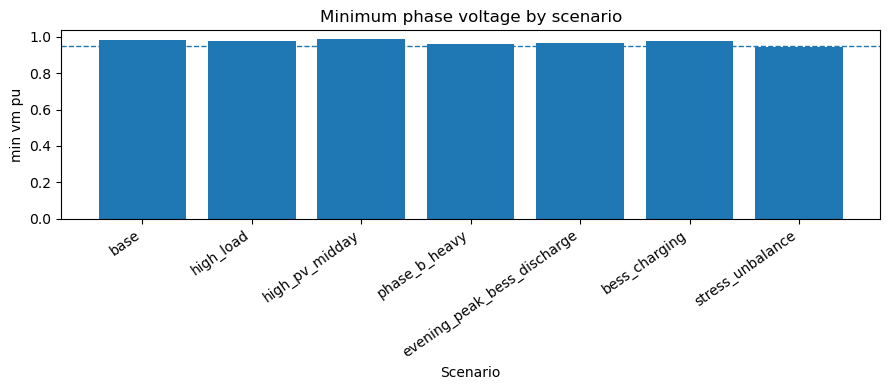

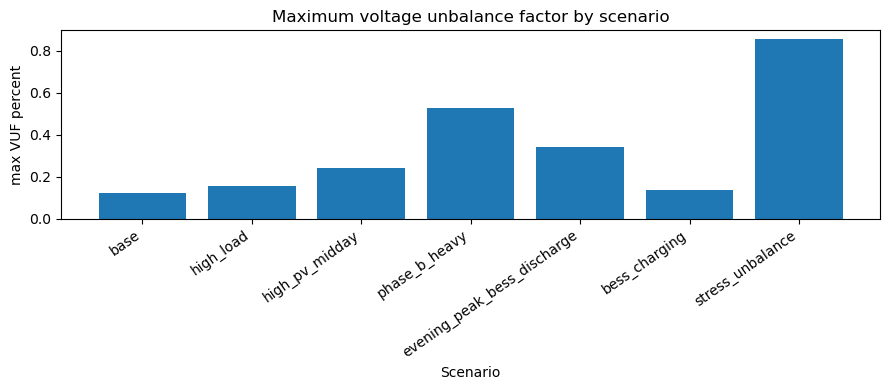

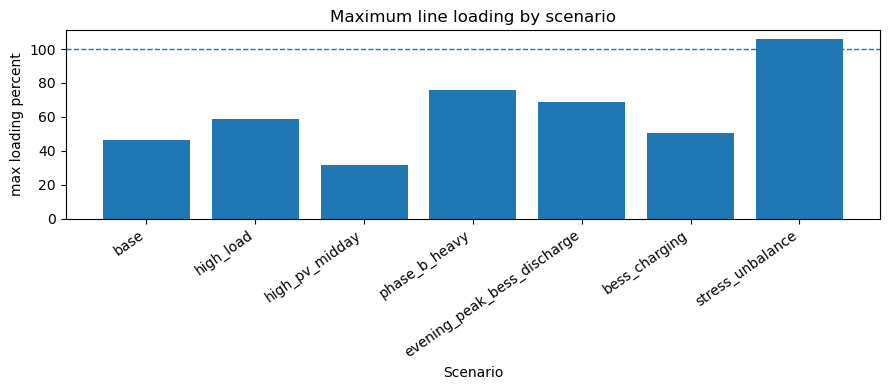

In [9]:
plt.figure(figsize=(9, 4))
plt.bar(scenario_summary["scenario_id"], scenario_summary["min_vm_pu"])
plt.axhline(0.95, linestyle="--", linewidth=1)
plt.title("Minimum phase voltage by scenario")
plt.xlabel("Scenario")
plt.ylabel("min vm pu")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
voltage_plot_path = OUTPUT_DIR / "week3_min_voltage_by_scenario.png"
plt.savefig(voltage_plot_path, dpi=160)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(scenario_summary["scenario_id"], scenario_summary["max_vuf_percent"])
plt.title("Maximum voltage unbalance factor by scenario")
plt.xlabel("Scenario")
plt.ylabel("max VUF percent")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
vuf_plot_path = OUTPUT_DIR / "week3_max_vuf_by_scenario.png"
plt.savefig(vuf_plot_path, dpi=160)
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(scenario_summary["scenario_id"], scenario_summary["max_line_loading_percent"])
plt.axhline(100.0, linestyle="--", linewidth=1)
plt.title("Maximum line loading by scenario")
plt.xlabel("Scenario")
plt.ylabel("max loading percent")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
loading_plot_path = OUTPUT_DIR / "week3_max_loading_by_scenario.png"
plt.savefig(loading_plot_path, dpi=160)
plt.show()


## 8. 导出 AI-facing features

Week 5 的 ML models 和 Week 7 的 GNN models 都需要一个结构稳定的 feature table。

Week 3 的 feature table 只包含 base-case scalar features。Week 4 会加入 contingency-specific features 和 post-contingency labels。

In [10]:
BASE_FEATURE_COLUMNS = [
    "scenario_id", "mode", "load_scale", "phase_a_factor", "phase_b_factor", "phase_c_factor",
    "pv_scale", "bess_p_discharge_mw", "min_vm_pu", "max_vm_pu", "max_vuf_percent",
    "max_line_loading_percent", "p_grid_mw", "q_grid_mvar", "p_load_mw", "q_load_mvar",
    "p_sgen_mw", "p_line_loss_mw", "converged",
    "p_load_a_mw", "p_load_b_mw", "p_load_c_mw",
    "p_sgen_a_mw", "p_sgen_b_mw", "p_sgen_c_mw",
]

basecase_ai_features = scenario_summary[BASE_FEATURE_COLUMNS].copy()


def assert_ai_feature_schema(features: pd.DataFrame) -> dict:
    missing = [c for c in BASE_FEATURE_COLUMNS if c not in features.columns]
    assert not missing, f"Missing feature columns: {missing}"
    assert features["scenario_id"].is_unique, "Feature scenario_id must be unique."
    numeric = features.select_dtypes(include=[np.number])
    assert np.isfinite(numeric.to_numpy()).all(), "Numeric feature table contains NaN or inf."
    assert features["converged"].all(), "All Week 3 deterministic base cases should converge."
    return {"status": "passed", "n_rows": len(features), "n_features": features.shape[1]}

ai_feature_check = {"test": "ai_feature_schema", **assert_ai_feature_schema(basecase_ai_features)}
validation_summary = pd.concat([
    validation_summary,
    pd.DataFrame([ai_feature_check]).set_index("test"),
], axis=0)

# Export tables.
SCENARIO_TABLE.to_csv(OUTPUT_DIR / "week3_scenario_table.csv", index=False)
metadata.pv_config.to_csv(OUTPUT_DIR / "week3_device_config_pv.csv", index=False)
metadata.bess_config.to_csv(OUTPUT_DIR / "week3_device_config_bess.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "week3_scenario_security_summary.csv", index=False)
basecase_ai_features.to_csv(OUTPUT_DIR / "week3_basecase_ai_features.csv", index=False)
validation_summary.to_csv(OUTPUT_DIR / "week3_validation_summary.csv")
sample_random_scenarios(20, seed=SEED).to_csv(OUTPUT_DIR / "week3_random_scenario_sample.csv", index=False)

# A compact JSON manifest helps Week 4 scripts locate required files.
manifest = {
    "scenario_table": str((OUTPUT_DIR / "week3_scenario_table.csv").relative_to(PROJECT_ROOT)),
    "scenario_summary": str((OUTPUT_DIR / "week3_scenario_security_summary.csv").relative_to(PROJECT_ROOT)),
    "basecase_ai_features": str((OUTPUT_DIR / "week3_basecase_ai_features.csv").relative_to(PROJECT_ROOT)),
    "validation_summary": str((OUTPUT_DIR / "week3_validation_summary.csv").relative_to(PROJECT_ROOT)),
    "pv_config": str((OUTPUT_DIR / "week3_device_config_pv.csv").relative_to(PROJECT_ROOT)),
    "bess_config": str((OUTPUT_DIR / "week3_device_config_bess.csv").relative_to(PROJECT_ROOT)),
    "figures": [str(p.relative_to(PROJECT_ROOT)) for p in (voltage_plot_path, vuf_plot_path, loading_plot_path)],
}
(OUTPUT_DIR / "week3_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

display(basecase_ai_features.round(6))
display(pd.Series(manifest, name="week3_export_manifest").to_frame())


,scenario_id,mode,load_scale,phase_a_factor,phase_b_factor,phase_c_factor,pv_scale,bess_p_discharge_mw,min_vm_pu,max_vm_pu,max_vuf_percent,max_line_loading_percent,p_grid_mw,q_grid_mvar,p_load_mw,q_load_mvar,p_sgen_mw,p_line_loss_mw,converged,p_load_a_mw,p_load_b_mw,p_load_c_mw,p_sgen_a_mw,p_sgen_b_mw,p_sgen_c_mw
0,base,grid_connected,1.00,1.0,1.0,1.0,0.0,0.000,0.979597,1.000036,0.123794,46.680118,0.068932,0.013718,0.06800,0.013600,0.0000,0.000932,True,0.021000,0.026000,0.021000,0.000000,0.000000,0.000000
1,high_load,grid_connected,1.25,1.0,1.0,1.0,0.0,0.000,0.974366,1.000046,0.157374,58.597167,0.086468,0.017188,0.08500,0.017000,0.0000,0.001468,True,0.026250,0.032500,0.026250,0.000000,0.000000,0.000000
2,high_pv_midday,grid_connected,0.75,1.0,1.0,1.0,1.0,0.000,0.986129,1.004857,0.241601,31.426609,0.033383,0.010248,0.05100,0.010200,0.0180,0.000383,True,0.015750,0.019500,0.015750,0.008000,0.002000,0.008000
3,phase_b_heavy,grid_connected,1.00,1.0,1.6,1.0,0.0,0.000,0.960213,1.000151,0.525884,75.827699,0.085312,0.016941,0.08360,0.016720,0.0000,0.001712,True,0.021000,0.041600,0.021000,0.000000,0.000000,0.000000
4,evening_peak_bess_discharge,grid_connected,1.30,1.0,1.2,1.0,0.1,0.008,0.966822,1.000099,0.342553,68.567156,0.086979,0.019240,0.09516,0.019032,0.0098,0.001619,True,0.027300,0.040560,0.027300,0.003467,0.002867,0.003467
5,bess_charging,grid_connected,1.00,1.0,1.0,1.0,0.2,-0.008,0.978358,1.000039,0.135695,50.676777,0.073485,0.013738,0.07600,0.013600,0.0036,0.001085,True,0.023667,0.028667,0.023667,0.001600,0.000400,0.001600
6,stress_unbalance,grid_connected,1.35,1.0,1.6,0.8,0.8,-0.008,0.943815,1.004199,0.853825,105.748808,0.103916,0.021846,0.11519,0.021438,0.0144,0.003126,True,0.031017,0.058827,0.025347,0.006400,0.001600,0.006400


,week3_export_manifest
scenario_table,03_week03_microgrid_scenario_generation/output...
scenario_summary,03_week03_microgrid_scenario_generation/output...
basecase_ai_features,03_week03_microgrid_scenario_generation/output...
validation_summary,03_week03_microgrid_scenario_generation/output...
pv_config,03_week03_microgrid_scenario_generation/output...
bess_config,03_week03_microgrid_scenario_generation/output...
figures,[03_week03_microgrid_scenario_generation/outpu...


## 9. 学生练习

1. 新增 `phase_c_heavy` scenario，并与 `phase_b_heavy` 比较 VUF。
2. 新增 `low_load_high_pv` scenario，观察 `max_vm_pu` 是否上升。
3. 生成 50 个 random scenarios，并按 `max_vuf_percent` 排序。
4. 用下面的规则增加一个 binary base-case risk flag：
   $$
   \mathbb{I}(\min V < 0.95 \text{ or } \max loading > 100\%).
   $$
5. 解释为什么 Week 3 base-case features 还不足以构成 N-1 security labels。
6. 写一段话说明 Week 4 如何把每个 scenario 变成多个样本 \((x_t,c)\)。

### Optional research extension

把 teaching feeder 替换为从 `ieee_european_lv_asymmetric` 中抽取的 reduced feeder。保留同一套 validation suite。不要在 validation 通过之前运行大规模数据集。